In [3]:
from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/Early-Sepsis-Detection"

Mounted at /content/drive
/content/drive/MyDrive/Early-Sepsis-Detection


In [4]:
import importlib; from src import sequence_builder as sb; importlib.reload(sb)

<module 'src.sequence_builder' from '/content/drive/MyDrive/Early-Sepsis-Detection/src/sequence_builder.py'>

In [5]:
!pip install xgboost lightgbm catboost -q
!pip install optuna -q
!pip install tensorflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 19.7 MB/s eta 0:00:00


# 14 — Deep Learning: LSTM/GRU
### Early Sepsis Detection — Phase 16

Builds a sequence model on the raw (LOCF-filled) hourly time series —
a fundamentally different input representation from Phase 8's aggregated
patient-level features (mean/std/slope/etc). Uses the SAME leakage-safe
primary window (6h) and the SAME train/val/test patient split as every
other model.

**We do not assume deep learning will outperform the tuned LightGBM from
Phase 15** — with only ~1,724 positive training patients and short (≤6h)
sequences, tree models on engineered features often win in this regime.
This is checked empirically, not assumed either way.


In [6]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

from src import config
from src import target as tgt
from src import sequence_builder as sb
from src import evaluate as ev

tf.random.set_seed(config.RANDOM_SEED)
np.random.seed(config.RANDOM_SEED)


## 1. Rebuild the leakage-safe window and load the LOCF-filled cleaned data

In [7]:
raw_df = pd.read_parquet(config.INTERIM_LONG_PARQUET)
cleaned_df = pd.read_parquet(config.INTERIM_DIR / "sepsis_hourly_cleaned.parquet")

window_table = tgt.build_patient_level_window_labels(raw_df, config.PRIMARY_PREDICTION_WINDOW_HOURS)
sliced_cleaned = tgt.slice_features_to_window(cleaned_df, window_table)
print("Sliced (LOCF-filled) shape:", sliced_cleaned.shape)


2026-09-15 07:35:45,500 | WARNING | src.target | Window=6h: excluding 965/40336 total patients (370 due to onset_hour<=1, 595 due to no data within the usable window despite a later onset).


Sliced (LOCF-filled) shape: (219373, 45)


## 2. Load the SAME split as every other model (Phase 10)

In [8]:
split_lookup = pd.read_parquet(config.PROCESSED_DIR / "patient_split_assignment.parquet")
train_ids = split_lookup.loc[split_lookup["split"] == "train", config.PATIENT_ID_COL].to_numpy()
val_ids = split_lookup.loc[split_lookup["split"] == "val", config.PATIENT_ID_COL].to_numpy()
test_ids = split_lookup.loc[split_lookup["split"] == "test", config.PATIENT_ID_COL].to_numpy()

patient_df = pd.read_parquet(config.PROCESSED_PATIENT_LEVEL_PARQUET)
label_lookup = patient_df.set_index(config.PATIENT_ID_COL)["label"]

y_train = label_lookup.reindex(train_ids).to_numpy()
y_val = label_lookup.reindex(val_ids).to_numpy()
y_test = label_lookup.reindex(test_ids).to_numpy()
print(f"Train: {len(train_ids)} | Val: {len(val_ids)} | Test: {len(test_ids)}")


Train: 27560 | Val: 5905 | Test: 5906


## 3. Build padded sequences and scale (fit on TRAIN only)

In [9]:
MAX_LEN = config.PRIMARY_PREDICTION_WINDOW_HOURS

X_train_raw, seq_vars = sb.build_sequences(sliced_cleaned, train_ids, max_len=MAX_LEN)
X_val_raw, _ = sb.build_sequences(sliced_cleaned, val_ids, max_len=MAX_LEN)
X_test_raw, _ = sb.build_sequences(sliced_cleaned, test_ids, max_len=MAX_LEN)

mean, std = sb.fit_sequence_scaler(X_train_raw)  # fit on TRAIN only

X_train = sb.fill_remaining_nans(sb.apply_sequence_scaler(X_train_raw, mean, std))
X_val = sb.fill_remaining_nans(sb.apply_sequence_scaler(X_val_raw, mean, std))
X_test = sb.fill_remaining_nans(sb.apply_sequence_scaler(X_test_raw, mean, std))

print("X_train shape:", X_train.shape, "(n_patients, timesteps, n_features)")
print("Sequence variables:", seq_vars)


X_train shape: (27560, 6, 9) (n_patients, timesteps, n_features)
Sequence variables: ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'WBC', 'Lactate']


### 3b. Diagnostic — confirm scaling did not introduce NaN/Inf

**Why check this?** Sparse variables (Lactate, WBC) frequently have NO
real measurement for many patients within this short window. An earlier
version of `fit_sequence_scaler()` used plain `mean()/std()`, which
silently produces NaN for such a column and poisons EVERY patient's
scaled value for that feature — this was caught empirically (the model
was previously observed stuck at loss=ln(2)/AUC=0.5 every epoch, i.e.
receiving no usable signal at all) and fixed to use `nanmean`/`nanstd`.
This cell verifies the fix before spending time training.


In [10]:
print("Scaler mean:", mean)
print("Scaler std: ", std)
assert not np.isnan(mean).any(), "BUG: scaler mean contains NaN!"
assert not np.isnan(std).any(), "BUG: scaler std contains NaN!"

for name, arr in [("X_train", X_train), ("X_val", X_val), ("X_test", X_test)]:
    n_nan = np.isnan(arr).sum()
    n_inf = np.isinf(arr).sum()
    print(f"{name}: NaN count={n_nan}, Inf count={n_inf} (both should be 0)")
    assert n_nan == 0, f"BUG: {name} still contains NaN after fill_remaining_nans!"
    assert n_inf == 0, f"BUG: {name} contains Inf!"

# Also confirm not every timestep is masked (a degenerate all-padded input
# would silently produce a frozen, non-learning model)
real_frac = (~np.all(X_train == sb.MASK_VALUE, axis=-1)).mean()
print(f"\nFraction of real (non-padded) timesteps in X_train: {real_frac:.3f}")
assert real_frac > 0.1, "BUG: almost all timesteps are padded/masked — check window slicing!"
print("\nPASSED: sequence data is clean and ready for training.")


Scaler mean: [ 84.20396   97.68956   36.64832  123.88696   83.53529   65.68385
  18.042013  11.835418   2.602117]
Scaler std:  [17.94917     3.0513954   0.77217895 23.900183   16.965145   14.100666
  5.1044803   9.326157    2.2182863 ]
X_train: NaN count=0, Inf count=0 (both should be 0)
X_val: NaN count=0, Inf count=0 (both should be 0)
X_test: NaN count=0, Inf count=0 (both should be 0)

Fraction of real (non-padded) timesteps in X_train: 0.930

PASSED: sequence data is clean and ready for training.


## 4. Build the LSTM model

Architecture per the project spec: Input -> Masking -> LSTM -> Dropout ->
Dense -> Sigmoid. Class weighting (Phase 12) is passed to `fit()` rather
than resampling data.


In [11]:
n_features = X_train.shape[-1]

model = models.Sequential([
    layers.Input(shape=(MAX_LEN, n_features)),
    layers.Masking(mask_value=sb.MASK_VALUE),
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc"), tf.keras.metrics.AUC(name="pr_auc", curve="PR")],
)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 6, 9)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,057 (82.25 KB)

 Trainable params: 21,057 (82.25 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train with early stopping and LR scheduling

In [12]:
n_pos = int(y_train.sum()); n_neg = len(y_train) - n_pos
class_weight = {0: len(y_train) / (2 * n_neg), 1: len(y_train) / (2 * n_pos)}
print("Class weights:", class_weight)

early_stop = callbacks.EarlyStopping(monitor="val_pr_auc", mode="max", patience=10, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)


Class weights: {0: 0.5333642978789286, 1: 7.993039443155452}
Epoch 1/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - auc: 0.6011 - loss: 0.6785 - pr_auc: 0.0899 - val_auc: 0.5961 - val_loss: 0.6690 - val_pr_auc: 0.0862 - learning_rate: 0.0010
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - auc: 0.6276 - loss: 0.6689 - pr_auc: 0.0998 - val_auc: 0.6139 - val_loss: 0.6557 - val_pr_auc: 0.0909 - learning_rate: 0.0010
Epoch 3/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - auc: 0.6392 - loss: 0.6639 - pr_auc: 0.1029 - val_auc: 0.6254 - val_loss: 0.6556 - val_pr_auc: 0.0976 - learning_rate: 0.0010
Epoch 4/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - auc: 0.6513 - loss: 0.6588 - pr_auc: 0.1058 - val_auc: 0.6391 - val_loss: 0.6400 - val_pr_auc: 0.1049 - learning_rate: 0.0010
Epoch 5/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - auc: 0.6646 - loss: 0.6527 - pr_auc: 0.1129 - val_auc: 0.6543 - val_loss: 0.6518 - val_pr_auc: 0.1111 - learning_rate: 0.0010
Epoch 6/100
108/108 ━━━━━━━━━

## 6. Training curves

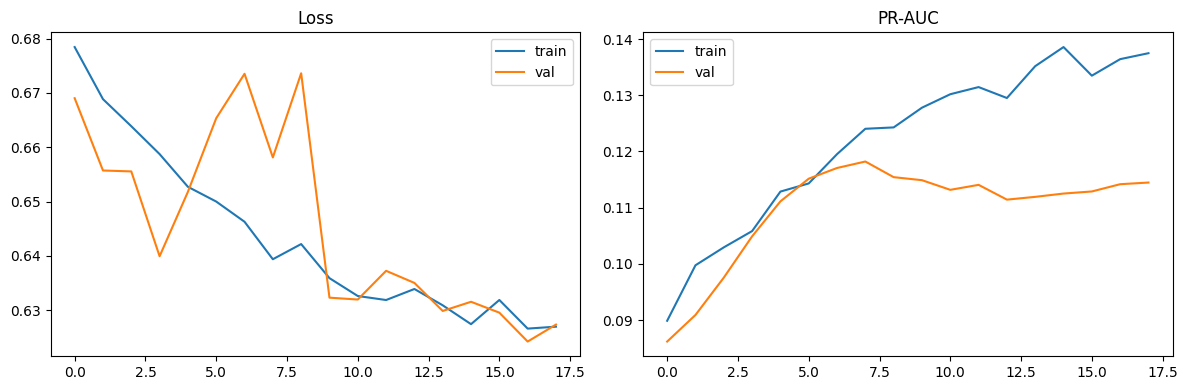

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(history.history["pr_auc"], label="train")
axes[1].plot(history.history["val_pr_auc"], label="val")
axes[1].set_title("PR-AUC"); axes[1].legend()
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "14_lstm_training_curves.png", dpi=150)
plt.show()


## 7. Evaluate on validation set (same evaluate.py as every other model)

In [14]:
lstm_val_prob = model.predict(X_val, verbose=0).ravel()
lstm_val_metrics = ev.compute_metrics(y_val, lstm_val_prob)
ev.print_metrics(lstm_val_metrics, "LSTM (val)")
ev.save_model_results("LSTM_val", lstm_val_metrics)


--- LSTM (val) (threshold=0.5) ---
  ROC-AUC:            0.6640
  PR-AUC:             0.1201
  Precision:          0.1032
  Recall (Sensitivity): 0.6423
  Specificity:        0.6279
  F1:                 0.1778
  Brier score:        0.2324
  Confusion matrix:   TN=3476 FP=2060 FN=132 TP=237


2026-09-15 07:37:14,192 | INFO | src.evaluate | Saved/updated results for 'LSTM_val' in /content/drive/MyDrive/Early-Sepsis-Detection/reports/tables/model_comparison.csv
INFO:src.evaluate:Saved/updated results for 'LSTM_val' in /content/drive/MyDrive/Early-Sepsis-Detection/reports/tables/model_comparison.csv


## 8. Compare against the best tree model (LightGBM tuned) — does deep learning win here?

In [15]:
results = pd.read_csv(config.TABLES_DIR / "model_comparison.csv")
compare_models = ["LightGBM_tuned_val", "CatBoost_tuned_val", "LSTM_val"]
comparison = results[results["model"].isin(compare_models)]
display(comparison[["model", "roc_auc", "pr_auc", "recall_sensitivity", "specificity", "f1"]])


,model,roc_auc,pr_auc,recall_sensitivity,specificity,f1
7,LightGBM_tuned_val,0.760980,0.239682,0.490515,0.850795,0.263081
8,CatBoost_tuned_val,0.739415,0.218891,0.352304,0.915643,0.269151
9,LSTM_val,0.663994,0.120060,0.642276,0.627890,0.177794


## 9. Save the model

In [16]:
model.save(config.MODELS_DIR / "lstm_model.keras")
print("Saved LSTM model.")


Saved LSTM model.


---
### What to send back to Claude after running this notebook

- Section 5's training log (did it converge / early-stop reasonably, or
  run all 100 epochs?)
- Section 7's validation metrics
- Section 8's comparison table — **does the LSTM beat, match, or lose to
  LightGBM (tuned)?** Either answer is a valid, reportable result.

With that, **Phase 16 is complete**, and we move to **Phase 17 (comprehensive
Model Evaluation)** — bringing every model trained so far (baseline,
5 ML models, 2 tuned models, LSTM) into one final comparison table with
ROC/PR/calibration curves for all of them together.
